In [243]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy import stats, special
from sklearn import datasets
import sklearn
import collections
import itertools
import statsmodels
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.metrics import adjusted_rand_score
import numpy as np
from scipy.cluster import hierarchy
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.utils import resample
from sklearn.inspection._permutation_importance import _create_importances_bunch

import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from sklearn.decomposition import PCA

rng = np.random.default_rng()
np.set_printoptions(linewidth=100)

# Block 5

## Prac 4

### 1.
Проанализируйте данные по ирисам (`iris`): выполните кластеризацию методом k-средних;
1. Определите оптимальное кол-во кластеров на основе подходящего критерия; оцените устойчивость распределения;
2. Опишите свойства кластеров;
3. Найдите переменные, значимые для кластеризации.

In [2]:
iris = datasets.load_iris()
print(iris.feature_names)
iris_pd = StandardScaler().fit_transform(iris.data)
iris_pd = pd.DataFrame(data=iris_pd, columns=iris.feature_names)
iris_pd.head()

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


Метод локтя

In [3]:
K_range = range(1, 10)
inertias = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(iris_pd)
    inertias.append(kmeans.inertia_)

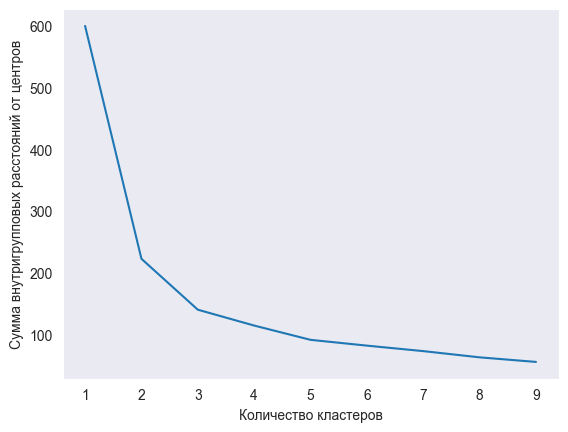

In [4]:
plt.plot(K_range, inertias)
plt.xlabel('Количество кластеров')
plt.ylabel('Сумма внутригрупповых расстояний от центров')
plt.grid()

In [5]:
K_CLUSTERS = 3

In [6]:
n_runs = 50
n_inits = range(1, 11)
min_aris = []
mean_aris = []
max_aris = []
for n_init in n_inits:
    labels_list = []

    for seed in range(n_runs):
        km = KMeans(n_clusters=K_CLUSTERS, random_state=seed, n_init=n_init)
        labels_list.append(km.fit_predict(iris_pd))

    # Средний ARI между всеми парами запусков
    aris = []
    for i in range(n_runs):
        for j in range(i + 1, n_runs):
            aris.append(adjusted_rand_score(labels_list[i], labels_list[j]))

    min_aris.append(np.min(aris))
    mean_aris.append(np.mean(aris))
    max_aris.append(np.max(aris))

[0.769 0.902 0.929 0.95  0.959 0.971 0.976 0.984 0.987 0.991]


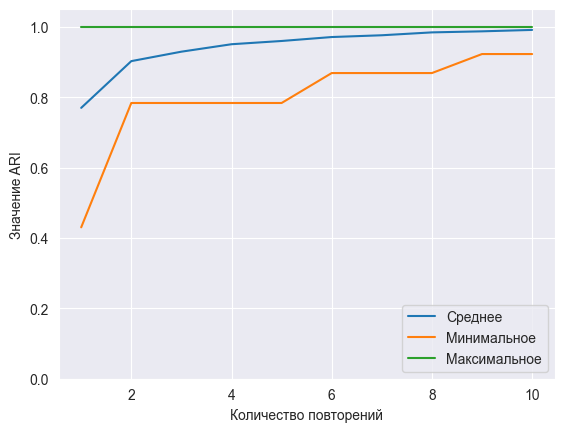

In [7]:
print(np.round(mean_aris, 3))
plt.plot(n_inits, mean_aris)
plt.plot(n_inits, min_aris)
plt.plot(n_inits, max_aris)
plt.xlabel('Количество повторений')
plt.ylabel('Значение ARI')
plt.legend(['Среднее', 'Минимальное', 'Максимальное'], loc='lower right')
plt.ylim((0, 1.05))
plt.grid(True)

In [8]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans = kmeans_final.fit_predict(iris_pd)
y_true = iris['target']

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['Cluster'] = y_kmeans

In [9]:
print("Размеры кластеров:")
cluster_sizes = df['Cluster'].value_counts().sort_index()
cluster_sizes

Размеры кластеров:


Cluster
0    53
1    50
2    47
Name: count, dtype: int64

In [10]:
print("\nСредние и стандартные отклонения признаков по кластерам:")
cluster_summary = df.groupby('Cluster')[iris.feature_names].agg(['mean', 'std']).round(3)
cluster_summary


Средние и стандартные отклонения признаков по кластерам:


sepal length (cm)        sepal width (cm)        petal length (cm)  \
                     mean    std             mean    std              mean   
Cluster                                                                      
0                   5.802  0.405            2.674  0.254             4.370   
1                   5.006  0.352            3.428  0.379             1.462   
2                   6.781  0.491            3.096  0.262             5.511   

               petal width (cm)         
           std             mean    std  
Cluster                                 
0        0.560            1.413  0.311  
1        0.174            0.246  0.105  
2        0.638            1.972  0.331

- Кластер 0: Средняя длина и меньшая ширина чашелистика (sepal), средние лепестки (petal)
- Кластер 1: Широкие чашелистики (sepal) и очень маленькие лепестки (petal)
- Кластер 2: Самый большой по размерам

In [11]:
ari_vs_true = adjusted_rand_score(y_true, y_kmeans)
print(f"\nARI между кластерами и истинными видами: {ari_vs_true:.4f}")


ARI между кластерами и истинными видами: 0.6201


In [12]:
# FeatureImpCluster
def permutation_importance_kmeans(model, X, metric, n_repeats=10, random_state=None):
    """
    Вычисляет важность признаков для k-means с помощью перестановок.

    Параметры:
    ----------
    model : обученная модель KMeans
    X : array-like, исходные данные
    metric : callable, функция для оценки качества кластеризации
            должна принимать (X, labels) и возвращать float
    n_repeats : int, количество повторений для каждого признака
    random_state : int, seed для воспроизводимости

    Возвращает:
    ----------
    result : dict, словарь с ключами 'importances_mean', 'importances_std', 'importances'
    """

    baseline_score = metric(X, model.labels_)

    n_features = X.columns.values
    importances = np.zeros((len(n_features), n_repeats))

    for feature_ in n_features:
        feature_idx = X.columns.get_loc(feature_)
        for repeat in range(n_repeats):
            X_permuted = X.copy()

            random_state_ = random_state
            if random_state is not None:
                random_state_ = random_state + feature_idx * n_repeats + repeat
            res = resample(X_permuted.loc[:, feature_], replace=False, random_state=random_state_)
            X_permuted.loc[:, feature_] = list(res)

            permuted_labels = model.predict(X_permuted)
            permuted_score = metric(X_permuted, permuted_labels)
            importances[feature_idx, repeat] = baseline_score - permuted_score

    b = _create_importances_bunch(baseline_score, importances)
    return b

In [13]:
result_kmeans = permutation_importance_kmeans(
    model=kmeans_final,
    X=iris_pd,
    metric=silhouette_score,
    n_repeats=10,
    random_state=42
)

In [14]:
def plot_permutation_importance(result, feature_names, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    perm_sorted_idx = result.importances_mean.argsort()

    tick_labels_dict = {"tick_labels": feature_names}
    ax.boxplot(result.importances[perm_sorted_idx].T, vert=False, **tick_labels_dict)
    ax.axvline(x=0, color="k", linestyle="--")
    ax.set_xlabel(f"Уменьшение метрики")
    ax.set_title("Permutation Importance")
    return ax

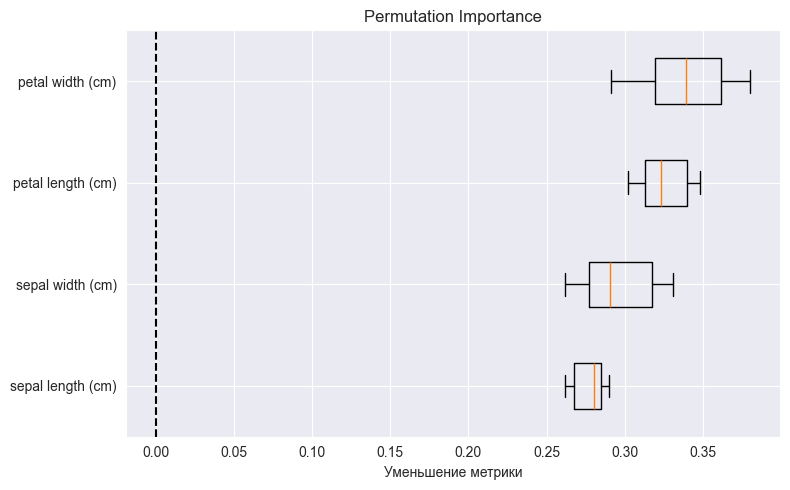


=== Результаты важности признаков ===
sepal length (cm)    | Важность (падение силуэта): 0.33972 ± 0.02831
sepal width (cm)     | Важность (падение силуэта): 0.32502 ± 0.01529
petal length (cm)    | Важность (падение силуэта): 0.27686 ± 0.01021
petal width (cm)     | Важность (падение силуэта): 0.29550 ± 0.02414


In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_permutation_importance(result_kmeans, iris.feature_names, ax)
plt.tight_layout()
plt.show()

print("\n=== Результаты важности признаков ===")
for i, name in enumerate(iris.feature_names):
    mean_imp = result_kmeans['importances_mean'][i]
    std_imp = result_kmeans['importances_std'][i]
    print(f"{name:20} | Важность (падение силуэта): {mean_imp:.5f} ± {std_imp:.5f}")

### 2.
Выполните иерархическую кластеризацию данных примера из лекции (лист КА) методом Варда. (Предполагается самостоятельная реализация метода.)

In [16]:
ka = pd.DataFrame(np.array([
    [130, 90, 165],
    [80, 75, 90],
    [140, 80, 100],
    [70, 76, 80],
    [60, 66, 110],
]), columns=["x1", "x2", "x3"])
ka

,x1,x2,x3
0,130,90,165
1,80,75,90
2,140,80,100
3,70,76,80
4,60,66,110


In [17]:
ka_s = StandardScaler().fit_transform(ka)
ka_s = pd.DataFrame(ka_s, columns=["x1", "x2", "x3"])
ka_s

,x1,x2,x3
0,1.042337,1.618046,1.883484
1,-0.490511,-0.308199,-0.639039
2,1.348907,0.333883,-0.302703
3,-0.797081,-0.179783,-0.975376
4,-1.103651,-1.463947,0.033634


array([[1.        , 3.        , 0.4728614 , 2.        ],
       [4.        , 5.        , 1.79137612, 3.        ],
       [0.        , 2.        , 2.55391332, 2.        ],
       [6.        , 7.        , 4.47715316, 5.        ]])

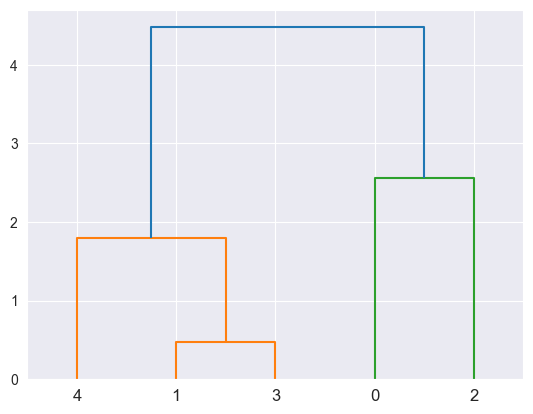

In [18]:
Z = hierarchy.linkage(ka_s, 'ward')
plt.figure()
dn = hierarchy.dendrogram(Z)
Z

In [19]:
import itertools


def ward_hierarchy(data, type_: int = 1):
    data = np.array(data)
    out_data = []
    clusters = [[i] for i in range(len(data))]
    current_clusters = {i for i in range(len(data))}

    while len(current_clusters) > 1:
        vars = []
        for i, j in itertools.combinations(current_clusters, 2):
            n_i, n_j = len(clusters[i]), len(clusters[j])
            mean_i = data[clusters[i]].mean(axis=0)
            mean_j = data[clusters[j]].mean(axis=0)
            delta = np.linalg.norm(mean_i - mean_j)
            if type_ == 0:
                delta = (n_i * n_j) / (n_i + n_j) * delta
            elif type_ == 1:
                delta = np.sqrt(2 * (n_i * n_j) / (n_i + n_j)) * delta

            vars.append((delta, (i, j)))

        var, (i, j) = min(vars)
        new_cluster = clusters[i] + clusters[j]
        out_data.append((i, j, var, len(new_cluster)))
        current_clusters.add(max(current_clusters) + 1)
        current_clusters.difference_update({i, j})
        clusters.append(new_cluster)

    return np.array(out_data)

array([[1.        , 3.        , 0.4728614 , 2.        ],
       [4.        , 5.        , 1.79137612, 3.        ],
       [0.        , 2.        , 2.55391332, 2.        ],
       [6.        , 7.        , 4.47715316, 5.        ]])

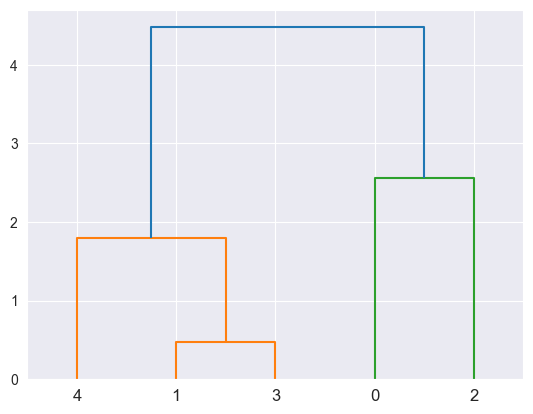

In [20]:
Z2 = ward_hierarchy(ka_s)
plt.figure()
dn = hierarchy.dendrogram(Z2)
Z2

### 3.
Проанализируйте данные по арестам (USArrests):
1. Выполните иерархическую кластеризацию, постройте дендрограмму, определите кол-во кластеров;
2. Оцените качество иерархической кластеризации, используя вероятность BP (Bootstrap Probability) встречаемости произвольного узла в бутстреп-копиях, а также несмещенную оценку бутстреп-вероятности AU (Approximately Unbiased);
3. Разбейте данные на кластеры методом k-средних, опишите свойства кластеров.

In [21]:
USArrests = pd.read_csv("../data/USArrests.csv", index_col="State")
USArrests.head()

,Murder,Assault,UrbanPop,Rape
State,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [22]:
arr_s = pd.DataFrame(StandardScaler().fit_transform(USArrests), index=USArrests.index, columns=USArrests.columns)
arr_s.head()

,Murder,Assault,UrbanPop,Rape
State,,,,
Alabama,1.255179,0.790787,-0.526195,-0.003451
Alaska,0.513019,1.118060,-1.224067,2.509424
Arizona,0.072361,1.493817,1.009122,1.053466
Arkansas,0.234708,0.233212,-1.084492,-0.186794
California,0.281093,1.275635,1.776781,2.088814


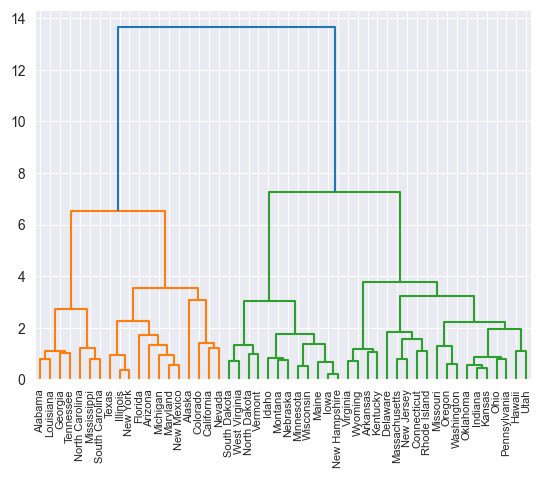

In [23]:
Z = hierarchy.linkage(arr_s, 'ward')
# Z = ward_hierarchy(arr_s)
plt.figure()
dn = hierarchy.dendrogram(Z, labels=USArrests.index, leaf_font_size=8)

In [24]:
np.round(
    hierarchy.linkage(arr_s, 'ward') - ward_hierarchy(arr_s),
    10)

array([[ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0., -0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0., -0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0., -0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  

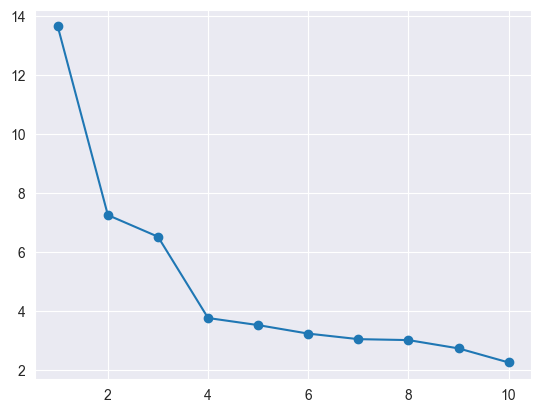

In [25]:
last_heights = Z[-10:, 2]
plt.figure()
plt.plot(range(1, len(last_heights) + 1), last_heights[::-1], 'o-')

k = 4

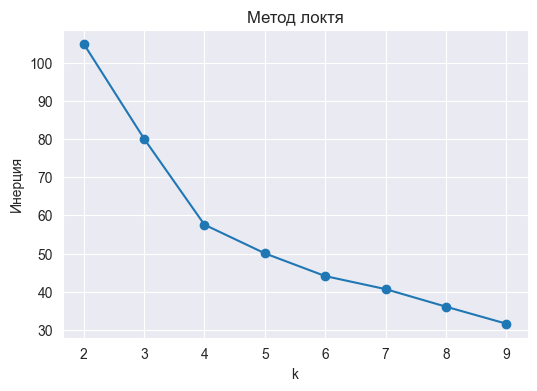

In [26]:
inertia = []
K_range = range(2, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(arr_s)
    inertia.append(kmeans.inertia_)

# Графики
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(K_range, inertia, 'o-')
ax.set_xlabel('k')
ax.set_ylabel('Инерция')
ax.set_title('Метод локтя')

plt.show()

2. R tut
3. 

In [27]:
kmeans_arr = KMeans(4, random_state=42).fit(arr_s)
y_kmeans = kmeans_arr.fit_predict(arr_s)

df = pd.DataFrame(USArrests, columns=arr_s.columns)
df['Cluster'] = y_kmeans

In [28]:
print("Размеры кластеров:")
cluster_sizes = df['Cluster'].value_counts().sort_index()
cluster_sizes

Размеры кластеров:


Cluster
0    13
1     8
2    12
3    17
Name: count, dtype: int64

In [29]:
print("\nСредние и стандартные отклонения признаков по кластерам:")
cluster_summary = df.groupby('Cluster')[arr_s.columns].agg(['mean']).round(3)
cluster_summary


Средние и стандартные отклонения признаков по кластерам:


,Murder,Assault,UrbanPop,Rape
,mean,mean,mean,mean
Cluster,,,,
0,3.600,78.538,52.077,12.177
1,13.938,243.625,53.750,21.412
2,10.967,264.000,76.500,33.608
3,5.853,141.176,73.647,19.335


Text(0.5, 1.0, 'Профили кластеров (средние значения)')

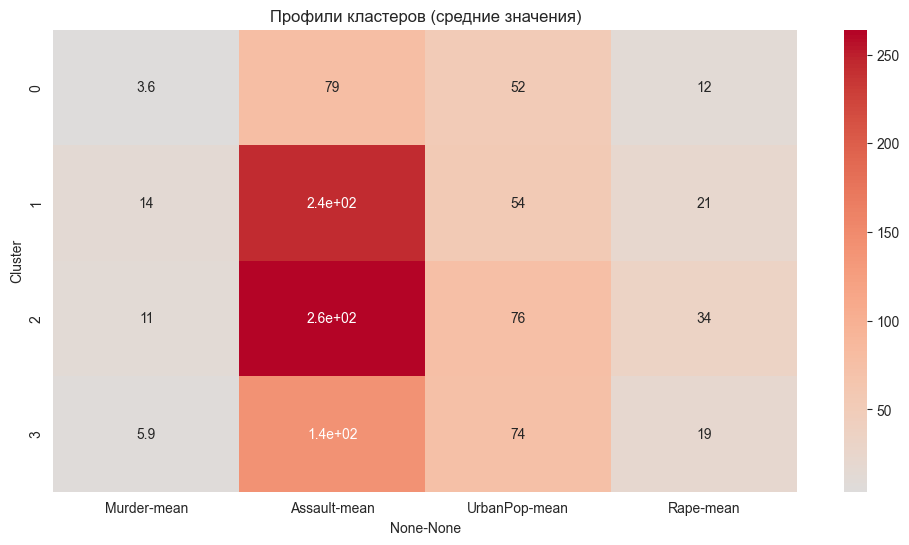

In [30]:
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_summary, annot=True, cmap='coolwarm', center=0)
plt.title('Профили кластеров (средние значения)')

In [31]:
for c in sorted(df['Cluster'].unique()):
    print(f"\nКластер {c}: {', '.join(df[df['Cluster'] == c].index.values)}")


Кластер 0: Idaho, Iowa, Kentucky, Maine, Minnesota, Montana, Nebraska, New Hampshire, North Dakota, South Dakota, Vermont, West Virginia, Wisconsin

Кластер 1: Alabama, Arkansas, Georgia, Louisiana, Mississippi, North Carolina, South Carolina, Tennessee

Кластер 2: Alaska, Arizona, California, Colorado, Florida, Illinois, Maryland, Michigan, Nevada, New Mexico, New York, Texas

Кластер 3: Connecticut, Delaware, Hawaii, Indiana, Kansas, Massachusetts, Missouri, New Jersey, Ohio, Oklahoma, Oregon, Pennsylvania, Rhode Island, Utah, Virginia, Washington, Wyoming


## Prac 5

### 1.
Данные по арестам (USArrests):
1. Добавить столбец с номерами кластеров (по результатам КА);
2. Методом главных компонент снизить размерность признакового пространства, дать название новым переменным;
3. Отобразить данные в координатах главных компонент (принадлежность наблюдения соответствующему кластеру отметить цветом или символом)


In [53]:
df = pd.DataFrame(arr_s, columns=arr_s.columns)
# df['Cluster'] = y_kmeans
Arr = df
Arr.head()

,Murder,Assault,UrbanPop,Rape
State,,,,
Alabama,1.255179,0.790787,-0.526195,-0.003451
Alaska,0.513019,1.118060,-1.224067,2.509424
Arizona,0.072361,1.493817,1.009122,1.053466
Arkansas,0.234708,0.233212,-1.084492,-0.186794
California,0.281093,1.275635,1.776781,2.088814


In [54]:
COV = np.cov(Arr.T, ddof=0)
COV

array([[1.        , 0.80187331, 0.06957262, 0.56357883],
       [0.80187331, 1.        , 0.2588717 , 0.66524123],
       [0.06957262, 0.2588717 , 1.        , 0.41134124],
       [0.56357883, 0.66524123, 0.41134124, 1.        ]])

In [55]:
er_ = np.linalg.eig(COV)
e_val = er_.eigenvalues
sorted_idx = np.argsort(e_val)[::-1]
e_val = e_val[sorted_idx]
e_vec = er_.eigenvectors[sorted_idx]
e_val, e_vec

(array([2.48024158, 0.98976515, 0.35656318, 0.17343009]),
 array([[ 0.53589947,  0.41818087,  0.6492278 , -0.34123273],
        [ 0.58318363,  0.1879856 , -0.74340748, -0.26814843],
        [ 0.54343209, -0.16731864,  0.08902432,  0.81777791],
        [ 0.27819087, -0.87280619,  0.13387773, -0.37801579]]))

In [56]:
np.cumsum(e_val) / e_val.sum()

array([0.62006039, 0.86750168, 0.95664248, 1.        ])

In [57]:
inform = pd.DataFrame(e_vec.T, index=Arr.columns, columns=[f"PCA {i + 1}" for i in range(e_vec.shape[0])])
inform

,PCA 1,PCA 2,PCA 3,PCA 4
Murder,0.535899,0.583184,0.543432,0.278191
Assault,0.418181,0.187986,-0.167319,-0.872806
UrbanPop,0.649228,-0.743407,0.089024,0.133878
Rape,-0.341233,-0.268148,0.817778,-0.378016


Text(0.5, 1.0, 'График каменистой осыпи')

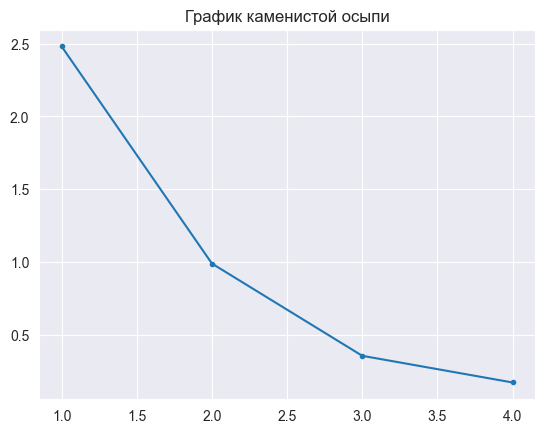

In [382]:
plt.plot(range(1, len(e_val) + 1), e_val, '.-')
plt.title("График каменистой осыпи")

In [348]:
def name_component(loadings_series, threshold=0.5, inf_coef=0.75):
    loadings2 = loadings_series.copy() ** 2
    argsort = (loadings2 ** 2).argsort()[::-1]
    loadings2 = loadings2.iloc[argsort]
    loadings_series = loadings_series.iloc[argsort]
    cumsum = np.cumsum(loadings2) / loadings2.sum()

    tr = np.where(cumsum > inf_coef)[0][0]
    return ' + '.join([f"{name} ({loadings_series[name]:.2f})" for name in
                       loadings_series.iloc[:tr + 1].index]) + f" [{cumsum.iloc[tr]:.2f}]"


def name_component0(loadings_series, threshold=0.5, inf_coef=0.75):
    high_loadings = loadings_series[loadings_series.abs() > threshold]
    if len(high_loadings) == 0:
        high_loadings = loadings_series.abs().nlargest(2)
    inform_coef = (high_loadings ** 2).sum() / (loadings_series ** 2).sum()
    return ' + '.join([f"{name} ({high_loadings[name]:.2f})" for name in high_loadings.index]) + f" [{inform_coef:.2f}]"


def all_name_components(inform_, threshold=0.5, inf_coef=0.75):
    component_names = {}
    for i in range(inform_.shape[1]):
        comp_name = name_component(inform_.iloc[:, i], threshold, inf_coef)
        component_names[f'PC{i + 1}'] = comp_name

    print(*component_names.items(), sep='\n')


all_name_components(inform)

('PC1', 'UrbanPop (0.65) + Murder (0.54) + Assault (0.42) [0.88]')
('PC2', 'UrbanPop (-0.74) + Murder (0.58) [0.89]')
('PC3', 'Rape (0.82) + Murder (0.54) [0.96]')
('PC4', 'Assault (-0.87) [0.76]')


In [59]:
PCA2 = Arr @ e_vec[:2].T
PCA2.head()

,0,1
State,,
Alabama,0.662899,1.272759
Alaska,-0.908518,0.746445
Arizona,0.959137,-0.709659
Arkansas,-0.417038,1.037027
California,1.124848,-1.477254


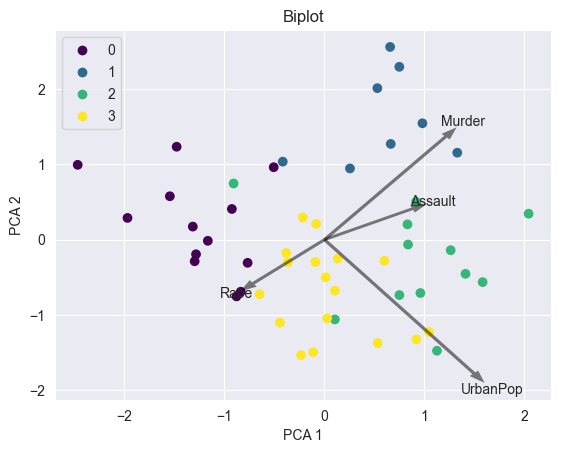

In [170]:
scatter2 = plt.scatter(PCA2[0], PCA2[1], c=y_kmeans, cmap='viridis')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Biplot')
plt.legend(*scatter2.legend_elements())

width = -0.0075 * np.min([np.subtract(*plt.xlim()), np.subtract(*plt.ylim())])
scale_ = np.abs(PCA2).max(axis=0).to_numpy()
# scale_ = 1
for name in inform.index:
    arrow = inform.loc[name][:2] * scale_
    plt.arrow(0, 0, *arrow, color='k', alpha=0.5, width=width, ec='none',
              length_includes_head=True)
    plt.text(*(arrow * 1.05), name,
             ha='center', va='center')



In [61]:
PCA3 = Arr @ e_vec[:3].T
PCA3.head()

,0,1,2
State,,,
Alabama,0.662899,1.272759,0.500125
Alaska,-0.908518,0.746445,2.034898
Arizona,0.959137,-0.709659,0.740718
Arkansas,-0.417038,1.037027,-0.160775
California,1.124848,-1.477254,1.805680


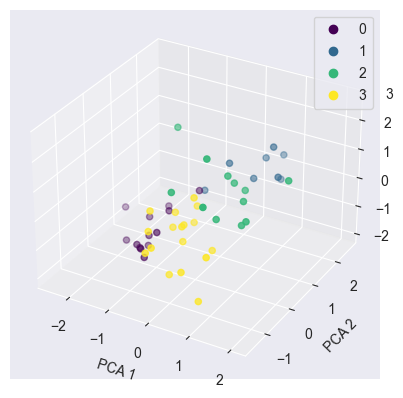

In [89]:
# %matplotlib qt
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
scatter3 = ax.scatter(PCA3[0], PCA3[1], PCA3[2], c=y_kmeans, cmap='viridis')
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
plt.legend(*scatter3.legend_elements())

In [63]:
%matplotlib inline

### 2.
Визуально проанализировать данные по людям (лист pop)
1. Сделать предположения о том, какие переменные могли бы быть зависимыми в регрессионной модели.

32 человека, из которых 16 представляют Северную Европу (Скандинавия) и столько же – Южную (Средиземноморье). Для баланса выбрано одинаковое количество мужчин и женщин – по 16 человек
- Height Рост: в сантиметрах
- Weight Вес: в килограммах
- Shoes Обувь: размер по европейскому стандарту
- Age Возраст: в годах
- Income Доход: в тысячах евро в год
- Beer Пиво: потребление в литрах в год
- Wine Вино: потребление в литрах в год
- Sex Пол: мужской: 0, или женский: 1
- Strength Сила: индекс, основанный на проверке физических способностей
- Region Регион: север : –1, или юг: +1
- IQ: Коэффициент интеллекта, измеряемый по стандартному тесту
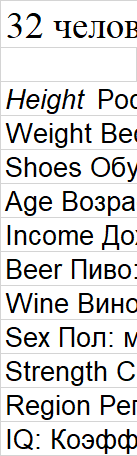
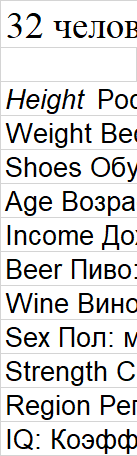
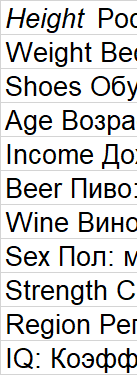

In [110]:
df_pop = pd.read_csv("../data/pop.csv", decimal=',')

In [112]:
df_pop.head()

,Height,Weight,Shoes,Strength,Age,IQ,Income,Beer,Wine,Sex,Region
0,198,92,48,98,48,100,45.0,420,115,0,-1
1,184,84,44,92,33,130,33.0,350,102,0,-1
2,183,83,44,91,37,127,34.0,320,98,0,-1
3,182,80,42,85,35,140,30.0,398,65,0,-1
4,180,80,43,84,36,129,30.0,388,63,0,-1


In [204]:
df_pop2 = df_pop.copy()
df_pop2['Sex_label'] = df_pop['Sex'].map({0: 'Male', 1: 'Female'})
df_pop2['Region_label'] = df_pop['Region'].map({-1: 'North', 1: 'South'})
df_pop2.head()

,Height,Weight,Shoes,Strength,Age,IQ,Income,Beer,Wine,Sex,Region,Sex_label,Region_label
0,198,92,48,98,48,100,45.0,420,115,0,-1,Male,North
1,184,84,44,92,33,130,33.0,350,102,0,-1,Male,North
2,183,83,44,91,37,127,34.0,320,98,0,-1,Male,North
3,182,80,42,85,35,140,30.0,398,65,0,-1,Male,North
4,180,80,43,84,36,129,30.0,388,63,0,-1,Male,North


In [114]:
pop_s = pd.DataFrame(StandardScaler().fit_transform(df_pop), columns=df_pop.columns)
pop_s.head()

,Height,Weight,Shoes,Strength,Age,IQ,Income,Beer,Wine,Sex,Region
0,2.512955,1.841312,2.110299,2.290893,1.447858,-1.263230,1.998242,1.912075,-0.340614,-1.0,-1.0
1,1.098628,1.306266,1.067371,1.457841,-0.153460,1.242350,0.632895,1.127059,-0.607460,-1.0,-1.0
2,0.997605,1.239385,1.067371,1.318999,0.273558,0.991792,0.746674,0.790623,-0.689566,-1.0,-1.0
3,0.896582,1.038742,0.545908,0.485947,0.060049,2.077543,0.291558,1.665356,-1.366945,-1.0,-1.0
4,0.694535,1.038742,0.806639,0.347105,0.166804,1.158831,0.291558,1.553211,-1.407998,-1.0,-1.0


In [196]:
pop_s2 = pop_s.copy()
pop_s2['Sex_label'] = pop_s['Sex'].map({-1.: 'Male', 1.: 'Female'})
pop_s2['Region_label'] = pop_s['Region'].map({-1.: 'North', 1.: 'South'})
pop_s2.head()

,Height,Weight,Shoes,Strength,Age,IQ,Income,Beer,Wine,Sex,Region,Sex_label,Region_label
0,2.512955,1.841312,2.110299,2.290893,1.447858,-1.263230,1.998242,1.912075,-0.340614,-1.0,-1.0,Male,North
1,1.098628,1.306266,1.067371,1.457841,-0.153460,1.242350,0.632895,1.127059,-0.607460,-1.0,-1.0,Male,North
2,0.997605,1.239385,1.067371,1.318999,0.273558,0.991792,0.746674,0.790623,-0.689566,-1.0,-1.0,Male,North
3,0.896582,1.038742,0.545908,0.485947,0.060049,2.077543,0.291558,1.665356,-1.366945,-1.0,-1.0,Male,North
4,0.694535,1.038742,0.806639,0.347105,0.166804,1.158831,0.291558,1.553211,-1.407998,-1.0,-1.0,Male,North


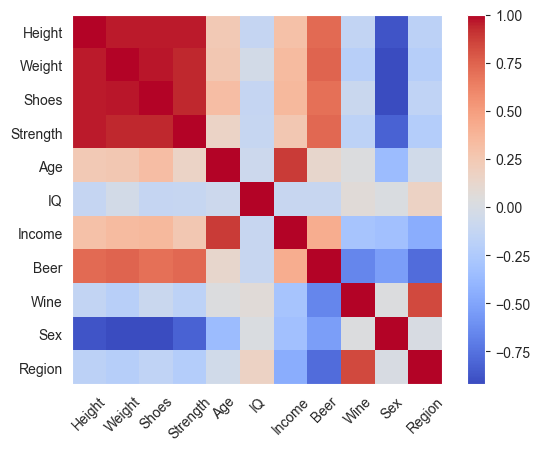

In [128]:
plt.imshow(np.corrcoef(pop_s.T), cmap='coolwarm')
plt.grid(False)
L = len(pop_s.columns)
plt.xticks(range(L), pop_s.columns, rotation=45)
plt.yticks(range(L), pop_s.columns)
plt.colorbar()

In [115]:
K_range_pop = range(1, 10)
inertias_pop = []

for k in K_range_pop:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pop_s)
    inertias_pop.append(kmeans.inertia_)

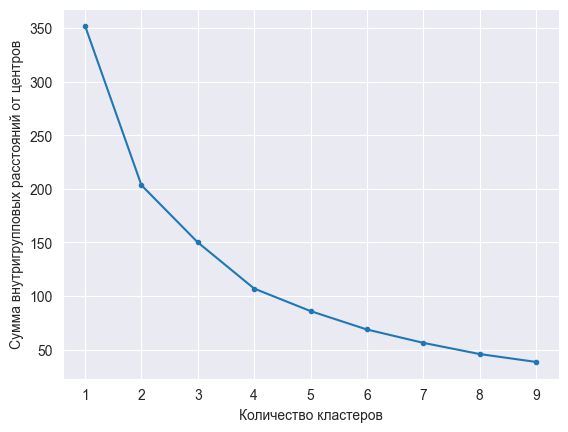

In [118]:
plt.plot(K_range_pop, inertias_pop, '.-')
plt.xlabel('Количество кластеров')
plt.ylabel('Сумма внутригрупповых расстояний от центров')
plt.grid(True)

In [171]:
pop_s.columns

Index(['Height', 'Weight', 'Shoes', 'Strength', 'Age', 'IQ', 'Income', 'Beer',
       'Wine', 'Sex', 'Region'],
      dtype='object')

In [240]:
%matplotlib inline

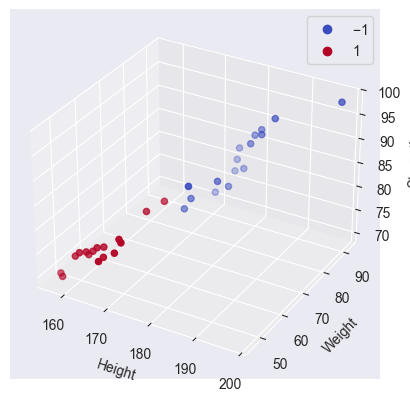

In [241]:
# %matplotlib qt
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
labels = ['Height', 'Weight', 'Strength']
scatter3 = ax.scatter(*[df_pop2[l] for l in labels], c=pop_s['Sex'], cmap='coolwarm')
ax.set_xlabel(labels[0])
ax.set_ylabel(labels[1])
ax.set_zlabel(labels[2])
plt.legend(*scatter3.legend_elements())

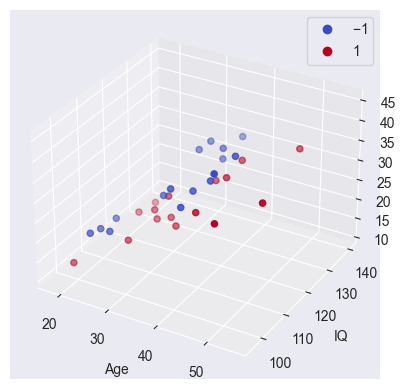

In [242]:
# %matplotlib qt
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
labels = ['Age', 'IQ', 'Income']
scatter3 = ax.scatter(*[df_pop2[l] for l in labels], c=pop_s['Region'], cmap='coolwarm')
ax.set_xlabel(labels[0])
ax.set_ylabel(labels[1])
ax.set_zlabel(labels[2])
plt.legend(*scatter3.legend_elements())

Сила

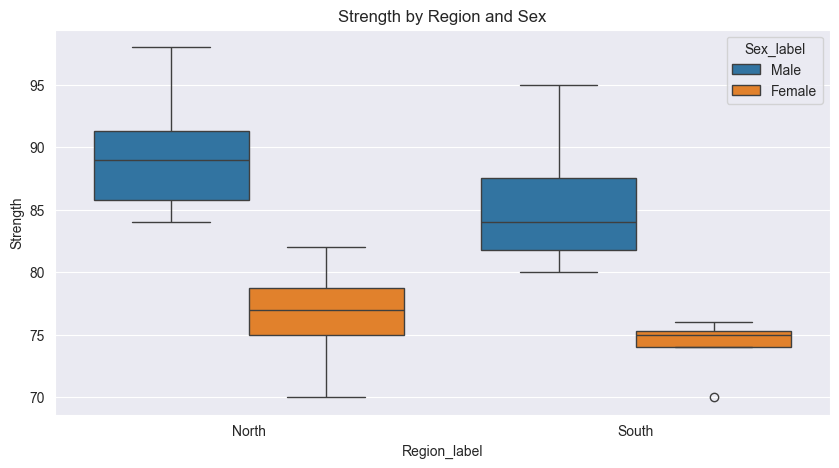

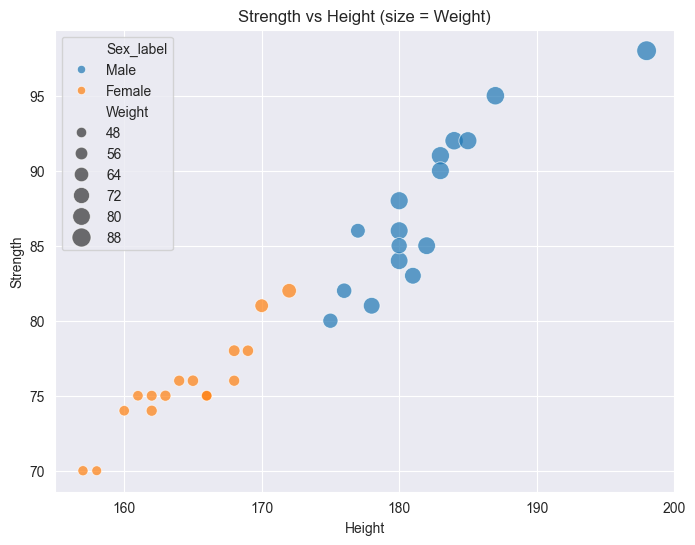

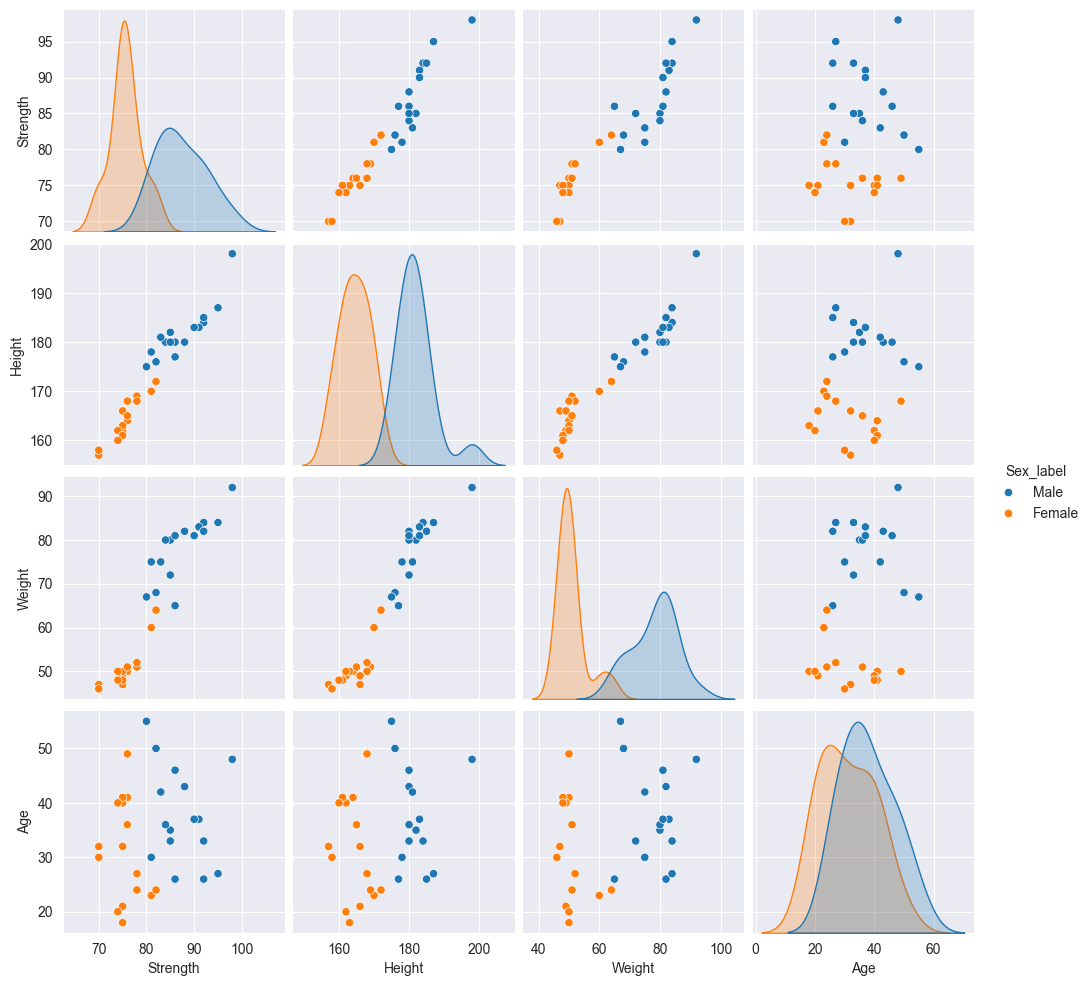

In [205]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_pop2, x='Region_label', y='Strength', hue='Sex_label')
plt.title('Strength by Region and Sex')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pop2, x='Height', y='Strength', hue='Sex_label', size='Weight', sizes=(50, 200), alpha=0.7)
plt.title('Strength vs Height (size = Weight)')
plt.show()

sns.pairplot(df_pop2[['Strength', 'Height', 'Weight', 'Age', 'Sex_label']], hue='Sex_label')
plt.show()

In [220]:
ols_str = OLS(df_pop2['Strength'], sm.add_constant(df_pop2[['Weight', 'Sex']]))
res = ols_str.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Strength   R-squared:                       0.891
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     118.0
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           1.17e-14
Time:                        21:05:52   Log-Likelihood:                -73.188
No. Observations:                  32   AIC:                             152.4
Df Residuals:                      29   BIC:                             156.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         42.4311      5.851      7.252      0.000      30.464      54.398
Weight         0.5748      0.074      7.726      0.000       0.423       0.727
Sex            4.0217      2.225      1.807      0.081      -0.529       8.572
==============================================================================
Omnibus:                        0.547   Durbin-Watson:                   1.542
Prob(Omnibus):                  0.761   Jarque-Bera (JB):                0.076
Skew:                           0.094   Prob(JB):                        0.963
Kurtosis:                       3.146   Cond. No.                         931.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [222]:
ols_we = OLS(df_pop2['Weight'], sm.add_constant(df_pop2[['Height', 'Age']]))
res = ols_we.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Weight   R-squared:                       0.922
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                     170.2
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           9.44e-17
Time:                        21:06:57   Log-Likelihood:                -91.244
No. Observations:                  32   AIC:                             188.5
Df Residuals:                      29   BIC:                             192.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -186.2918     13.634    -13.664      0.000    -214.176    -158.408
Height         1.4407      0.081     17.793      0.000       1.275       1.606
Age            0.0388      0.086      0.454      0.654      -0.136       0.214
==============================================================================
Omnibus:                        1.368   Durbin-Watson:                   1.590
Prob(Omnibus):                  0.504   Jarque-Bera (JB):                1.301
Skew:                          -0.392   Prob(JB):                        0.522
Kurtosis:                       2.398   Cond. No.                     3.10e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.1e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Пиво

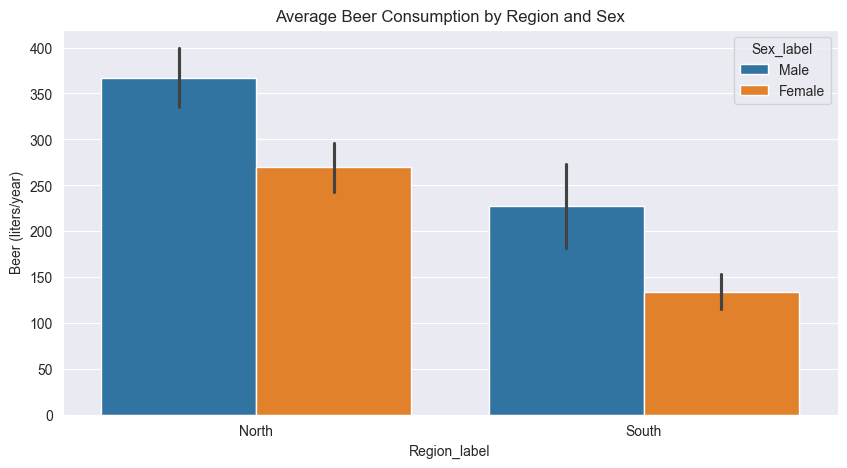

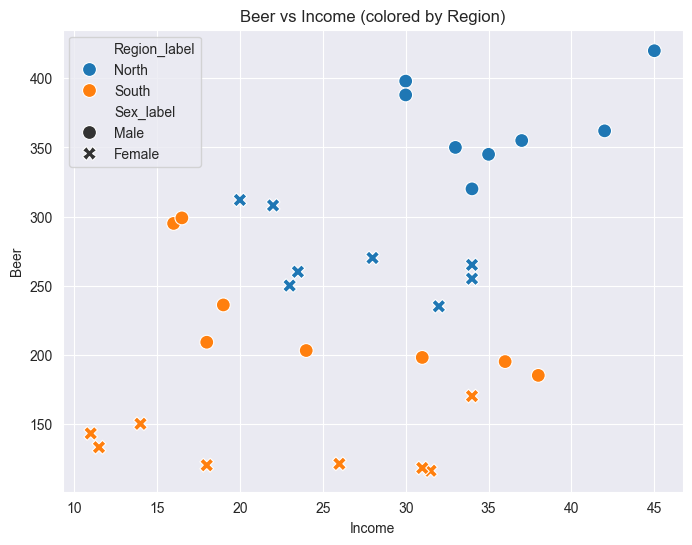

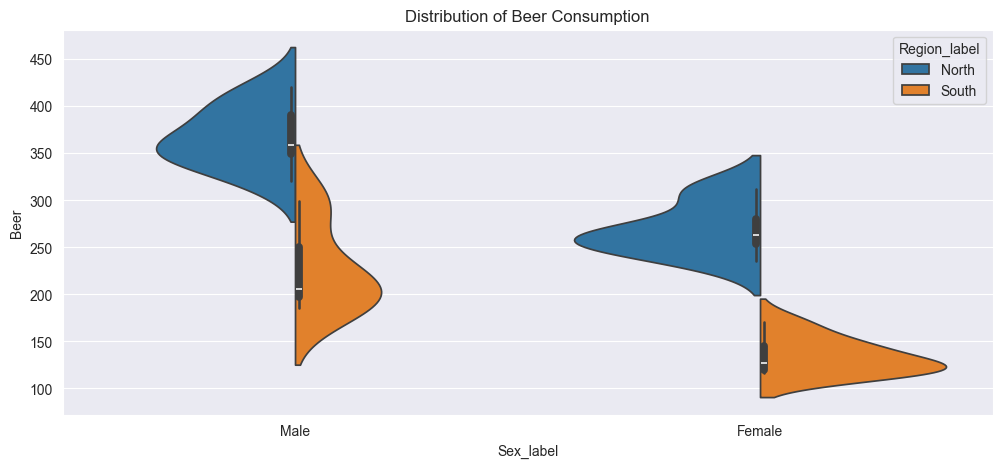

In [207]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_pop2, x='Region_label', y='Beer', hue='Sex_label', errorbar='sd')
plt.title('Average Beer Consumption by Region and Sex')
plt.ylabel('Beer (liters/year)')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pop2, x='Income', y='Beer', hue='Region_label', style='Sex_label', s=100)
plt.title('Beer vs Income (colored by Region)')
plt.show()

plt.figure(figsize=(12, 5))
sns.violinplot(data=df_pop2, x='Sex_label', y='Beer', hue='Region_label', split=True)
plt.title('Distribution of Beer Consumption')
plt.show()

In [211]:
ols_beer = OLS(df_pop2['Beer'], sm.add_constant(df_pop2[['Income', 'Region', 'Age', 'Sex']]))
res = ols_beer.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   Beer   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     63.65
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           2.36e-13
Time:                        21:01:10   Log-Likelihood:                -151.59
No. Observations:                  32   AIC:                             313.2
Df Residuals:                      27   BIC:                             320.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        337.0171     24.125     13.970      0.000     287.517     386.517
Income        -4.4966      2.763     -1.628      0.115     -10.165       1.172
Region       -85.5397     11.319     -7.557      0.000    -108.764     -62.316
Age            2.5568      2.307      1.108      0.278      -2.177       7.291
Sex         -104.3854     11.404     -9.153      0.000    -127.785     -80.986
==============================================================================
Omnibus:                        6.667   Durbin-Watson:                   1.364
Prob(Omnibus):                  0.036   Jarque-Bera (JB):                5.316
Skew:                           0.970   Prob(JB):                       0.0701
Kurtosis:                       3.469   Cond. No.                         216.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Вино

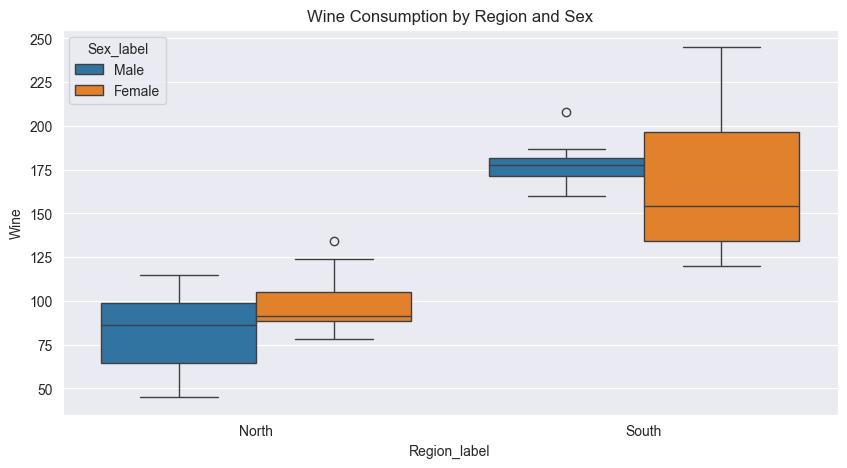

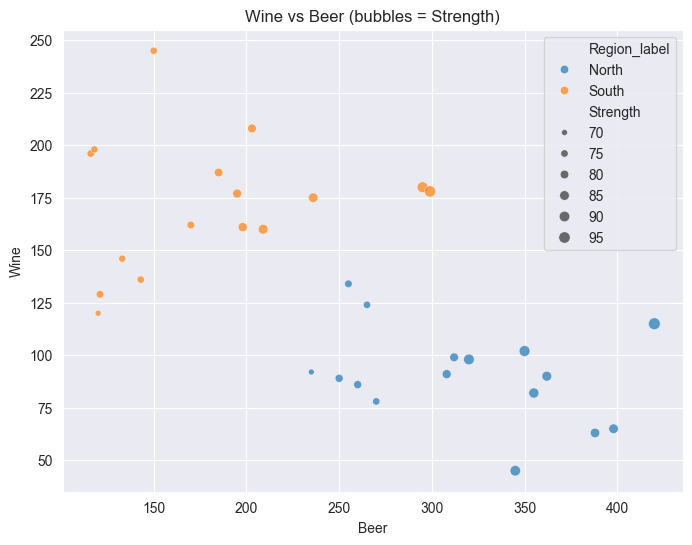

<Figure size 800x600 with 0 Axes>

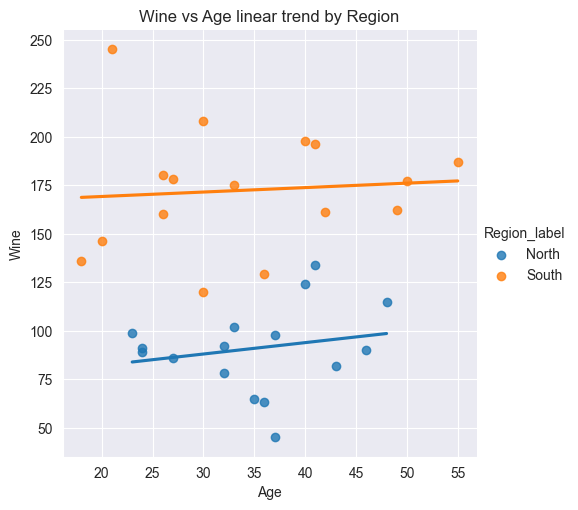

In [212]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_pop2, x='Region_label', y='Wine', hue='Sex_label')
plt.title('Wine Consumption by Region and Sex')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pop2, x='Beer', y='Wine', hue='Region_label', size='Strength', alpha=0.7)
plt.title('Wine vs Beer (bubbles = Strength)')
plt.show()

plt.figure(figsize=(8, 6))
sns.lmplot(data=df_pop2, x='Age', y='Wine', hue='Region_label', ci=None)
plt.title('Wine vs Age linear trend by Region')
plt.show()

Доход

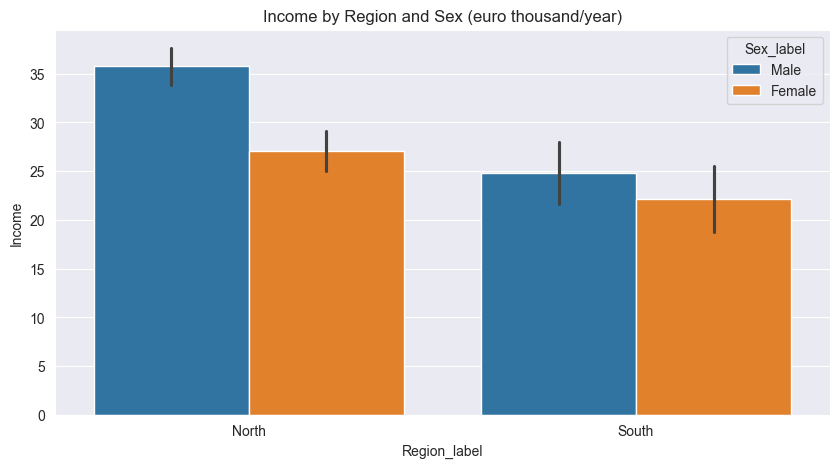

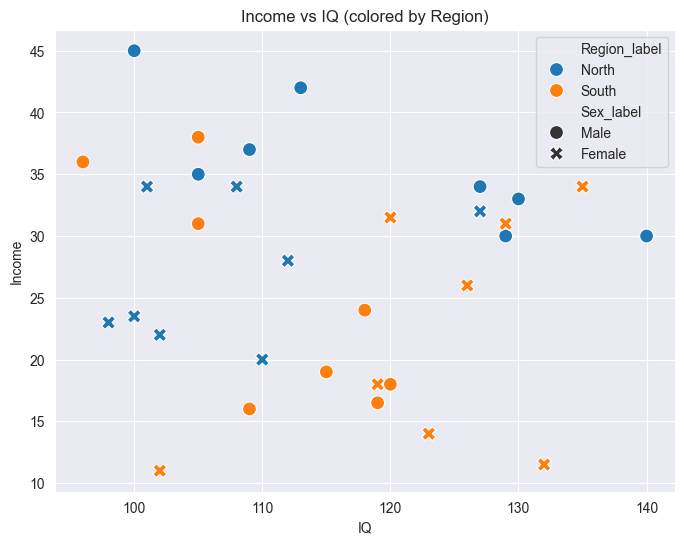

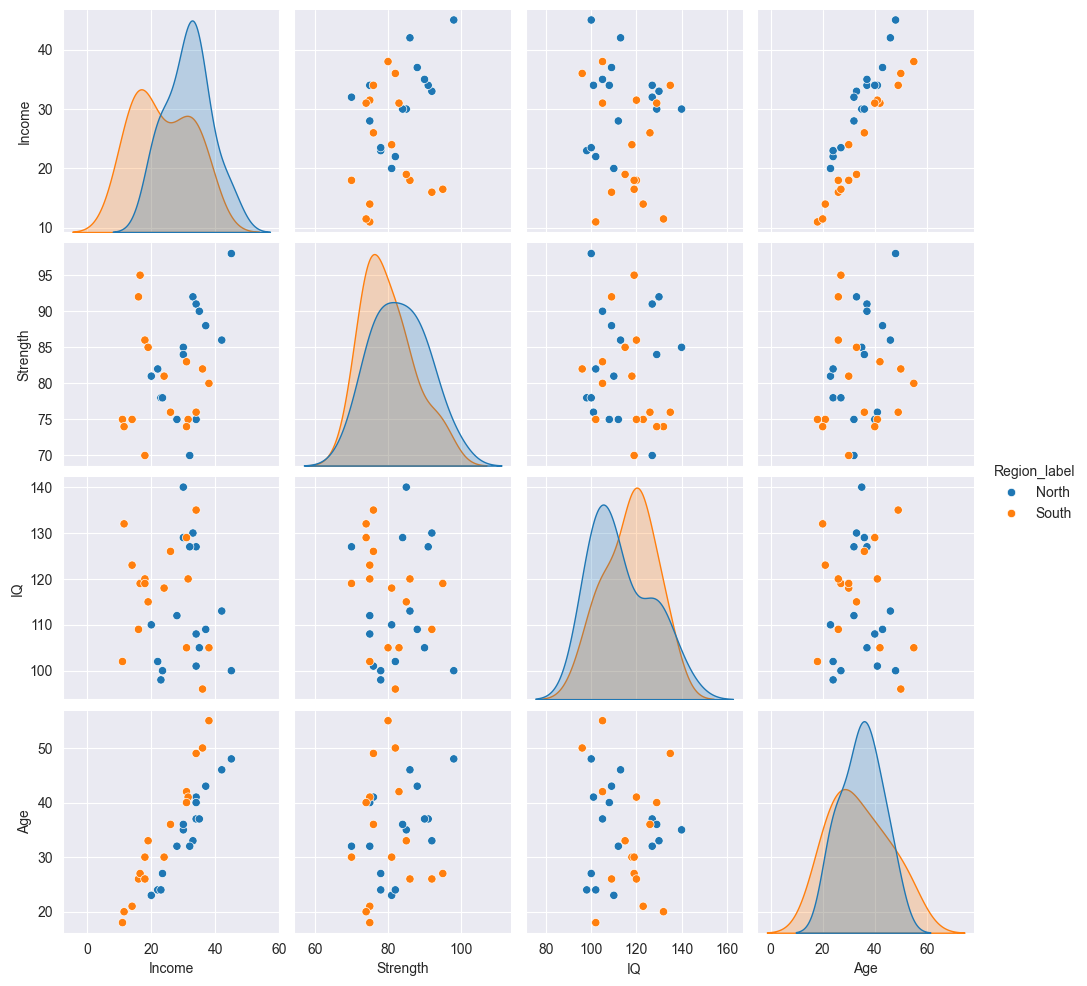

In [225]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_pop2, x='Region_label', y='Income', hue='Sex_label', errorbar='se')
plt.title('Income by Region and Sex (euro thousand/year)')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pop2, x='IQ', y='Income', hue='Region_label', style='Sex_label', s=100)
plt.title('Income vs IQ (colored by Region)')
plt.show()

sns.pairplot(df_pop2[['Income', 'Strength', 'IQ', 'Age', 'Region_label']], hue='Region_label')
plt.show()

KMeans

In [366]:
kmeans_pop = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_pop = kmeans_pop.fit_predict(pop_s)

In [369]:
list(zip(df_pop["Sex"], df_pop["Region"], labels_pop))

[(0, -1, np.int32(2)),
 (0, -1, np.int32(2)),
 (0, -1, np.int32(2)),
 (0, -1, np.int32(2)),
 (0, -1, np.int32(2)),
 (0, -1, np.int32(2)),
 (0, -1, np.int32(2)),
 (0, -1, np.int32(2)),
 (0, 1, np.int32(0)),
 (0, 1, np.int32(0)),
 (0, 1, np.int32(0)),
 (0, 1, np.int32(0)),
 (0, 1, np.int32(0)),
 (0, 1, np.int32(0)),
 (0, 1, np.int32(0)),
 (0, 1, np.int32(0)),
 (1, -1, np.int32(1)),
 (1, -1, np.int32(1)),
 (1, -1, np.int32(1)),
 (1, -1, np.int32(1)),
 (1, -1, np.int32(1)),
 (1, -1, np.int32(1)),
 (1, -1, np.int32(1)),
 (1, -1, np.int32(1)),
 (1, 1, np.int32(3)),
 (1, 1, np.int32(3)),
 (1, 1, np.int32(3)),
 (1, 1, np.int32(3)),
 (1, 1, np.int32(3)),
 (1, 1, np.int32(3)),
 (1, 1, np.int32(3)),
 (1, 1, np.int32(3))]

In [251]:
pca3_pop = PCA(n_components=3)
pca3_pop.fit(pop_s)

PCA(n_components=3)

In [257]:
pca3_pop.explained_variance_ratio_.sum()

np.float64(0.8664455101438652)

In [273]:
inform_pop = pd.DataFrame(pca3_pop.components_, columns=pop_s.columns, index=["PC 1", "PC 2", "PC 3"]).T
inform_pop.T

,Height,Weight,Shoes,Strength,Age,IQ,Income,Beer,Wine,Sex,Region
PC 1,0.393823,0.400102,0.396532,0.384622,0.160110,-0.056642,0.215690,0.352313,-0.143162,-0.361465,-0.170318
PC 2,0.169030,0.143922,0.187025,0.145055,-0.025456,0.106369,-0.254332,-0.288836,0.561829,-0.260057,0.592741
PC 3,-0.096736,-0.089938,-0.026103,-0.160261,0.719381,-0.053388,0.593766,-0.188081,0.186827,-0.031694,0.109488


In [351]:
all_name_components(inform_pop)

('PC1', 'Weight (0.40) + Shoes (0.40) + Height (0.39) + Strength (0.38) + Sex (-0.36) [0.75]')
('PC2', 'Region (0.59) + Wine (0.56) + Beer (-0.29) [0.75]')
('PC3', 'Age (0.72) + Income (0.59) [0.87]')


In [354]:
pop_pc3 = pca3_pop.transform(pop_s)

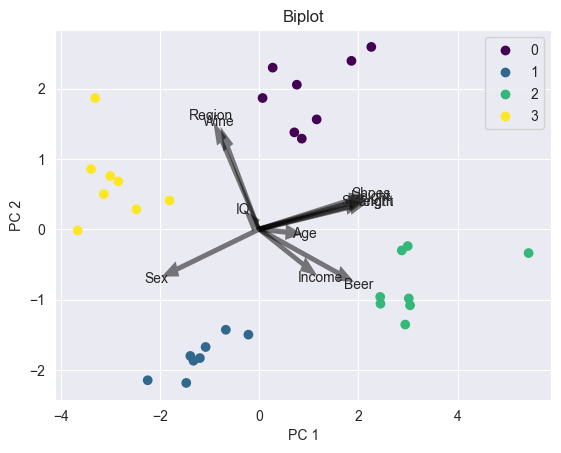

In [370]:
scatter2 = plt.scatter(pop_pc3[:, 0], pop_pc3[:, 1], c=labels, cmap='viridis')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('Biplot')
plt.legend(*scatter2.legend_elements())

width = -0.0075 * np.min([np.subtract(*plt.xlim()), np.subtract(*plt.ylim())])
scale_ = np.abs(pop_pc3[:, [0, 1]]).max(axis=0)
# scale_ = 1
for name in inform_pop.index:
    arrow = inform_pop.loc[name][:2] * scale_
    plt.arrow(0, 0, *arrow, color='k', alpha=0.5, width=width, ec='none', length_includes_head=True)
    plt.text(*(arrow * 1.05), name, ha='center', va='center')



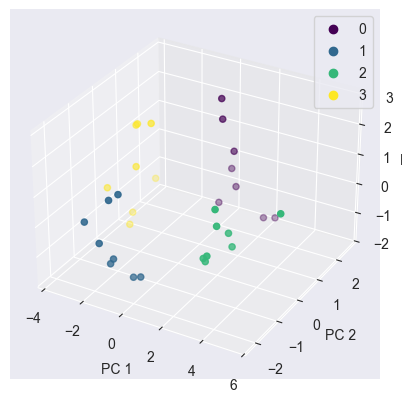

In [375]:
# %matplotlib qt
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
scatter3 = ax.scatter(pop_pc3[:, 0], pop_pc3[:, 1], pop_pc3[:, 2], c=labels_pop, cmap='viridis')
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")
plt.legend(*scatter3.legend_elements())

In [374]:
%matplotlib inline

In [376]:
pca_pop = PCA()
pca_pop.fit(pop_s)

PCA()

Text(0.5, 1.0, 'График каменистой осыпи')

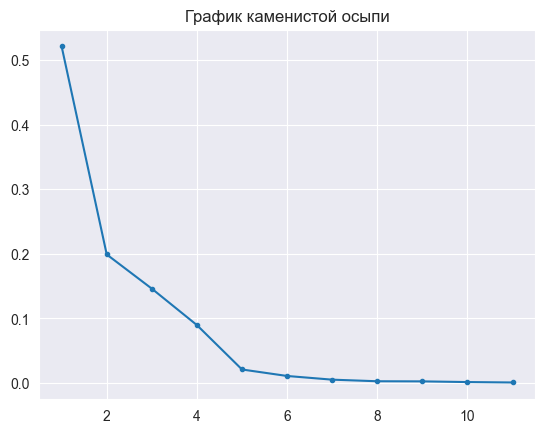

In [381]:
ratios = pca_pop.explained_variance_ratio_
plt.plot(range(1, len(ratios) + 1), ratios, '.-')
plt.title("График каменистой осыпи")